In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

In [3]:
print("Trades:", trades.shape)
print("Sentiment:", sentiment.shape)

Trades: (211224, 16)
Sentiment: (2644, 4)


In [5]:
print(trades.isnull().sum())
print("Duplicates:", trades.duplicated().sum())

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64
Duplicates: 0


In [4]:
print(sentiment.isnull().sum())
print("Duplicates:", sentiment.duplicated().sum())

timestamp         0
value             0
classification    0
date              0
dtype: int64
Duplicates: 0


In [6]:
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    format='mixed',
    dayfirst=True,
    errors='coerce'
)
sentiment['date'] = pd.to_datetime(sentiment['date'], errors='coerce')
trades['date'] = trades['Timestamp IST'].dt.date
sentiment['date'] = sentiment['date'].dt.date
df = trades.merge(sentiment[['date','classification']], on='date', how='left')

In [9]:
df['win'] = df['Closed PnL'] > 0

In [8]:
df['is_long'] = df['Side'].apply(lambda x: 1 if x == 'BUY' else 0)

In [7]:
df['trade_count'] = 1

In [10]:
# aily PnL per trader
daily_pnl = df.groupby(['Account','date'])['Closed PnL'].sum().reset_index()

In [11]:
#Win rate
win_rate = df.groupby('Account')['win'].mean()

In [12]:
#Avg trade size
avg_size = df.groupby('Account')['Size USD'].mean()

In [13]:
#Trades per day
trades_per_day = df.groupby('date').size()

In [14]:
# Long/Short ratio
long_short_ratio = df.groupby('date')['is_long'].mean()

In [15]:
# Risk proxy (size instead of leverage)
risk_distribution = df['Size USD'].describe()

In [16]:
df.groupby('classification')['Closed PnL'].describe()
df.groupby('classification')['win'].mean()

classification
Extreme Fear     0.370607
Extreme Greed    0.464943
Fear             0.420768
Greed            0.384828
Neutral          0.396991
Name: win, dtype: float64

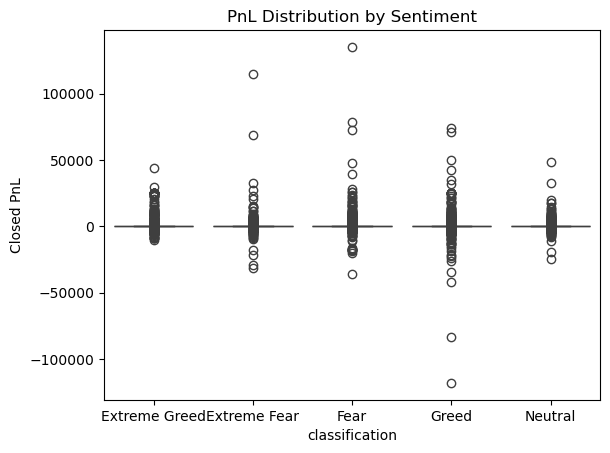

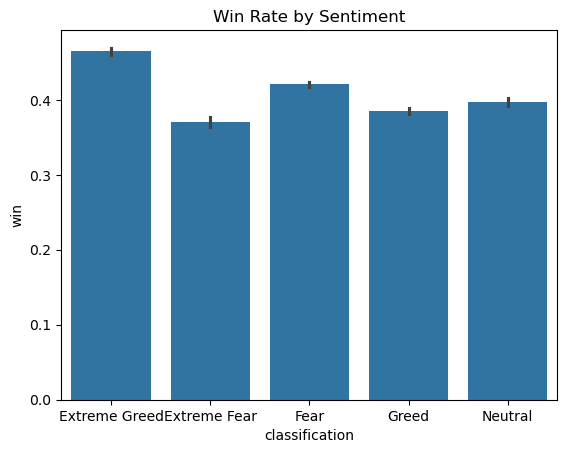

In [17]:
sns.boxplot(x='classification', y='Closed PnL', data=df)
plt.title("PnL Distribution by Sentiment")
plt.show()

sns.barplot(x='classification', y='win', data=df)
plt.title("Win Rate by Sentiment")
plt.show()

In [ ]:
# Trade size
df.groupby('classification')['Size USD'].mean()

In [ ]:
# Long/Short
df.groupby('classification')['Side'].value_counts(normalize=True)

In [18]:
#Trade frequency
df.groupby('classification')['trade_count'].sum()

classification
Extreme Fear     21400
Extreme Greed    39992
Fear             61837
Greed            50303
Neutral          37686
Name: trade_count, dtype: int64

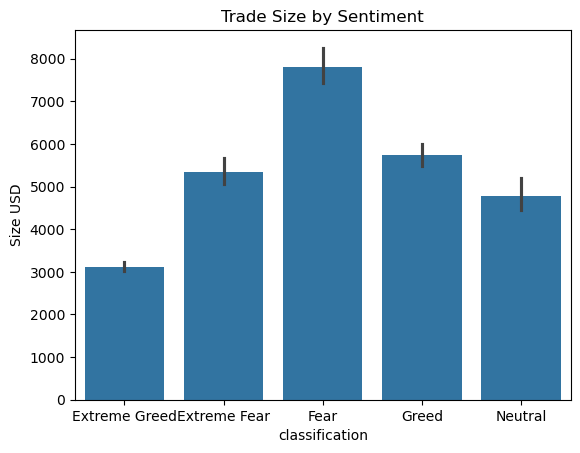

In [19]:
sns.barplot(x='classification', y='Size USD', data=df)
plt.title("Trade Size by Sentiment")
plt.show()

In [20]:
median_size = df['Size USD'].median()
df['size_group'] = df['Size USD'].apply(lambda x: 'High' if x > median_size else 'Low')

In [21]:
trade_counts = df['Account'].value_counts()
frequent = trade_counts[trade_counts > 100].index

df['trader_type'] = df['Account'].isin(frequent).map({
    True: 'Frequent',
    False: 'Rare'
})

In [22]:
profit = df.groupby('Account')['Closed PnL'].sum()
winners = profit[profit > 0].index

df['profit_type'] = df['Account'].isin(winners).map({
    True: 'Winner',
    False: 'Loser'
})

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

Accuracy: 0.6373298615220736


In [ ]:
df['profit_label'] = df['Closed PnL'].apply(lambda x: 1 if x > 0 else 0)

X = df[['Size USD','is_long']]
y = df['profit_label']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train,y_train)

print("Accuracy:", model.score(X_test,y_test))